# Entrenamiento SVM (multiclase) — Leads 3000

> Dataset: `algoritmos/leads_3000.csv`

Este notebook:
- Carga el dataset y prepara features (texto + categóricas + numérica).
- Entrena un modelo SVM multiclase.
- Evalúa con accuracy, precision, recall y matriz de confusión.
- Genera probabilidades (`score`) por predicción.
- Guarda modelo y vectorizador con `joblib`.

In [ ]:
# Imports y configuración
from __future__ import annotations

from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

import matplotlib.pyplot as plt

DATA_PATH = Path(r"C:\Users\MARIANA\Desktop\LAIDA\algoritmos\dataset.csv")
OUTPUT_DIR = Path(r"C:\Users\MARIANA\Desktop\LAIDA\algoritmos\outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2

pd.set_option("display.max_colwidth", 120)

In [2]:
# 1) Cargar dataset
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(3000, 6)


,lead_id,chuck_id,mensaje_chuck,intencion,pre_precio,lead_clase
0,L00001,CHUCK_04,"Excelente decision, te ayudo a completar tu compra ahora.",compra,0,tibio
1,L00002,CHUCK_01,"Claro, te comparto el precio actualizado del plan.",consulta_precio,1,caliente
2,L00003,CHUCK_01,Retomo la conversacion para ayudarte con la decision.,seguimiento,0,tibio
3,L00004,CHUCK_03,"Hola, un gusto saludarte. En que te asesoro?",saludo,0,frio
4,L00005,CHUCK_07,"El costo depende del paquete, te paso las opciones de precio.",consulta_precio,1,tibio


In [3]:
# 2) Preparación básica (selección de features y target)
TARGET_COL = "lead_clase"
TEXT_COL = "mensaje_chuck"
CAT_COLS = ["intencion", "chuck_id"]
NUM_COLS = ["pre_precio"]

missing_cols = [c for c in [TARGET_COL, TEXT_COL, *CAT_COLS, *NUM_COLS] if c not in df.columns]
if missing_cols:
    raise ValueError(f"Faltan columnas en el CSV: {missing_cols}")

# Limpieza mínima de nulos
df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)
for c in CAT_COLS:
    df[c] = df[c].fillna("missing").astype(str)
for c in NUM_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[TARGET_COL] = df[TARGET_COL].astype(str)

print("Distribución de clases:")
display(df[TARGET_COL].value_counts(dropna=False))

Distribución de clases:


lead_clase
tibio       1368
frio         879
caliente     753
Name: count, dtype: int64

In [4]:
# 3) Split train/test (estratificado)
X = df[[TEXT_COL, *CAT_COLS, *NUM_COLS]].copy()
y = df[TARGET_COL].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
 )

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (2400, 4) Test: (600, 4)


In [5]:
# 4) Preprocesamiento para SVM
text_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=2,
    max_features=50_000,
    strip_accents="unicode",
    sublinear_tf=True,
 )

categorical_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
 )

numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=False)),
    ]
 )

preprocess = ColumnTransformer(
    transformers=[
        ("tfidf_mensaje", text_vectorizer, TEXT_COL),
        ("cat", categorical_pipe, CAT_COLS),
        ("num", numeric_pipe, NUM_COLS),
    ],
    remainder="drop",
    sparse_threshold=0.3,
 )

# SVM lineal + calibración para obtener probabilidades
base_svm = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)
clf = CalibratedClassifierCV(base_svm, method="sigmoid", cv=3)

model = Pipeline(steps=[("preprocess", preprocess), ("clf", clf)])
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('tfidf_mensaje', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [6]:
# 5) Entrenamiento
model.fit(X_train, y_train)
print("Entrenamiento completo")

Entrenamiento completo


Accuracy:          0.7267
Precision (macro): 0.7772
Recall (macro):    0.7010
Precision (w):     0.7580
Recall (w):        0.7267

Classification report:

              precision    recall  f1-score   support

    caliente       0.76      0.66      0.71       151
        frio       0.92      0.59      0.72       176
       tibio       0.65      0.85      0.74       273

    accuracy                           0.73       600
   macro avg       0.78      0.70      0.72       600
weighted avg       0.76      0.73      0.73       600



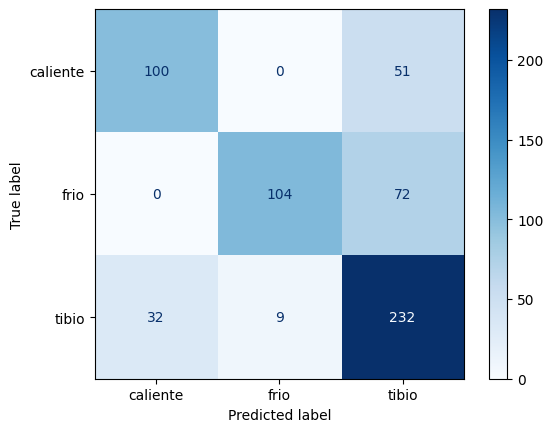

In [7]:
# 6) Evaluación (accuracy, precision, recall, matriz de confusión)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
rec_macro = recall_score(y_test, y_pred, average="macro", zero_division=0)
prec_weighted = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec_weighted = recall_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy:          {acc:.4f}")
print(f"Precision (macro): {prec_macro:.4f}")
print(f"Recall (macro):    {rec_macro:.4f}")
print(f"Precision (w):     {prec_weighted:.4f}")
print(f"Recall (w):        {rec_weighted:.4f}")

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

labels = sorted(y.unique().tolist())
cm = confusion_matrix(y_test, y_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(values_format="d", cmap="Blues")

In [8]:
# 7) Probabilidades por predicción (score)
proba = model.predict_proba(X_test)
classes = model.named_steps["clf"].classes_
proba_df = pd.DataFrame(proba, columns=[f"proba_{c}" for c in classes], index=X_test.index)

pred_df = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
}, index=X_test.index)

pred_df = pd.concat([pred_df, proba_df], axis=1)
pred_df["score_max"] = proba_df.max(axis=1)
pred_df["pred_clase_score"] = proba_df.idxmax(axis=1).str.replace("proba_", "", regex=False)

pred_df.head(10)

,y_true,y_pred,proba_caliente,proba_frio,proba_tibio,score_max,pred_clase_score
176,frio,frio,0.019464,0.920856,0.059680,0.920856,frio
2835,tibio,tibio,0.174949,0.011451,0.813600,0.813600,tibio
2992,tibio,caliente,0.769981,0.018517,0.211501,0.769981,caliente
881,frio,tibio,0.015627,0.245863,0.738510,0.738510,tibio
245,frio,tibio,0.018316,0.375675,0.606009,0.606009,tibio
2191,frio,tibio,0.015092,0.491884,0.493024,0.493024,tibio
2699,frio,frio,0.017247,0.911244,0.071509,0.911244,frio
1353,caliente,caliente,0.837698,0.015093,0.147209,0.837698,caliente
2237,tibio,tibio,0.193373,0.030229,0.776399,0.776399,tibio
2557,frio,tibio,0.018272,0.431024,0.550704,0.550704,tibio


In [9]:
# (Opcional) Guardar predicciones con score a CSV
preds_path = OUTPUT_DIR / "svm_predicciones_con_probabilidades.csv"
pred_df.to_csv(preds_path, index=True)
print("Guardado:", preds_path)

Guardado: C:\Users\MARIANA\Desktop\LAIDA\algoritmos\outputs\svm_predicciones_con_probabilidades.csv


In [10]:
# 8) Guardar modelo y vectorizador con joblib
model_path = OUTPUT_DIR / "svm_leads_pipeline.joblib"
vectorizer_path = OUTPUT_DIR / "tfidf_mensaje_vectorizer.joblib"

# Extraer el vectorizador ya entrenado desde el ColumnTransformer
fitted_vectorizer = model.named_steps["preprocess"].named_transformers_["tfidf_mensaje"]

joblib.dump(model, model_path)
joblib.dump(fitted_vectorizer, vectorizer_path)

print("Modelo guardado en:", model_path)
print("Vectorizador guardado en:", vectorizer_path)
print("Clases:", model.named_steps["clf"].classes_)

Modelo guardado en: C:\Users\MARIANA\Desktop\LAIDA\algoritmos\outputs\svm_leads_pipeline.joblib
Vectorizador guardado en: C:\Users\MARIANA\Desktop\LAIDA\algoritmos\outputs\tfidf_mensaje_vectorizer.joblib
Clases: ['caliente' 'frio' 'tibio']
